- Nate Diaz-Santana
- Applied Data Science

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

import ftfy
import re
from io import StringIO
import matplotlib.dates as mdates

# Optimizing Sponsored Content on Twitch: Game and Viewership Trends

## Data

### Imports

In [6]:
# Dumb code to fix formatting issues with accented characters, chinese characters and such.
# Mostly an aesthetic fix
with open('Twitch_game_data.csv', 'rb') as f:
    text = f.read().decode('utf-8', errors='replace')

game = pd.read_csv(StringIO(text))

def clean(s):
    if isinstance(s, str):
        s = ftfy.fix_text(s)
        return re.sub(r'<U\+([0-9A-F]{4})>', lambda m: chr(int(m.group(1),16)), s)
    return s

for col in game.select_dtypes(include='object'):
    game[col] = game[col].apply(clean)

In [7]:
game.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              21000 non-null  int64  
 1   Game              20999 non-null  object 
 2   Month             21000 non-null  int64  
 3   Year              21000 non-null  int64  
 4   Hours_watched     21000 non-null  int64  
 5   Hours_streamed    21000 non-null  int64  
 6   Peak_viewers      21000 non-null  int64  
 7   Peak_channels     21000 non-null  int64  
 8   Streamers         21000 non-null  int64  
 9   Avg_viewers       21000 non-null  int64  
 10  Avg_channels      21000 non-null  int64  
 11  Avg_viewer_ratio  21000 non-null  float64
dtypes: float64(1), int64(10), object(1)
memory usage: 1.9+ MB


In [8]:
game.head()

,Rank,Game,Month,Year,Hours_watched,Hours_streamed,Peak_viewers,Peak_channels,Streamers,Avg_viewers,Avg_channels,Avg_viewer_ratio
0,1,League of Legends,1,2016,94377226,1362044,530270,2903,129172,127021,1833,69.29
1,2,Counter-Strike: Global Offensive,1,2016,47832863,830105,372654,2197,120849,64378,1117,57.62
2,3,Dota 2,1,2016,45185893,433397,315083,1100,44074,60815,583,104.26
3,4,Hearthstone,1,2016,39936159,235903,131357,517,36170,53749,317,169.29
4,5,Call of Duty: Black Ops III,1,2016,16153057,1151578,71639,3620,214054,21740,1549,14.03


In [9]:
game.tail()

,Rank,Game,Month,Year,Hours_watched,Hours_streamed,Peak_viewers,Peak_channels,Streamers,Avg_viewers,Avg_channels,Avg_viewer_ratio
20995,196,Pokémon HeartGold/SoulSilver,9,2024,683902,10093,10600,42,1443,951,14,67.76
20996,197,Grounded,9,2024,683226,37779,39473,116,7076,950,52,18.08
20997,198,Ragnarok Online,9,2024,679965,28491,2539,75,1066,945,39,23.87
20998,199,Politics,9,2024,673799,16675,19746,210,957,937,23,40.41
20999,200,DARK SOULS III,9,2024,667767,47190,13288,139,7886,928,65,14.15


In [10]:
platform = pd.read_csv('Twitch_global_data.csv')

In [11]:
platform.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            105 non-null    int64  
 1   Month           105 non-null    int64  
 2   Hours_watched   105 non-null    int64  
 3   Avg_viewers     105 non-null    int64  
 4   Peak_viewers    105 non-null    int64  
 5   Streams         105 non-null    int64  
 6   Avg_channels    105 non-null    int64  
 7   Games_streamed  105 non-null    int64  
 8   Viewer_ratio    105 non-null    float64
dtypes: float64(1), int64(8)
memory usage: 7.5 KB


In [12]:
platform.head()

,year,Month,Hours_watched,Avg_viewers,Peak_viewers,Streams,Avg_channels,Games_streamed,Viewer_ratio
0,2016,1,480241904,646355,1275257,7701675,20076,12149,29.08
1,2016,2,441859897,635769,1308032,7038520,20427,12134,28.98
2,2016,3,490669308,660389,1591551,7390957,20271,12234,28.92
3,2016,4,377975447,525696,1775120,6869719,16791,12282,28.80
4,2016,5,449836631,605432,1438962,7535519,19394,12424,28.85


In [13]:
platform.tail()

,year,Month,Hours_watched,Avg_viewers,Peak_viewers,Streams,Avg_channels,Games_streamed,Viewer_ratio
100,2024,5,1727139900,2324548,4032587,22686570,91550,46363,25.90
101,2024,6,1617653502,2249865,4560410,22209935,92133,46752,24.78
102,2024,7,1660370134,2234683,6872963,23309553,93039,46904,24.24
103,2024,8,1711442710,2303422,4159346,23399616,93682,46965,25.14
104,2024,9,1698990192,2362990,4343770,21730541,90841,45635,26.46


### Time Index

In [15]:
game['date'] = pd.to_datetime(game['Year'].astype(str) + '-' + game['Month'].astype(str))
platform['date'] = pd.to_datetime(platform['year'].astype(str) + '-' + platform['Month'].astype(str))

## Univariative Analysis (Distributions)

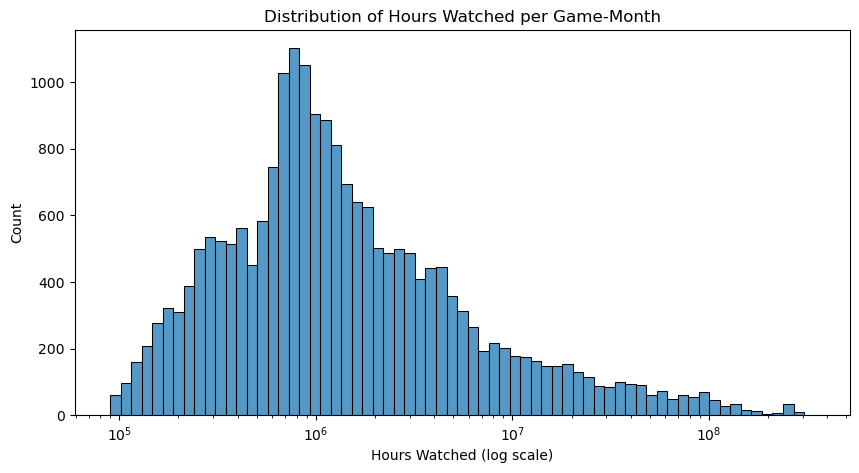

In [17]:
plt.figure(figsize=(10,5))
sb.histplot(game['Hours_watched'], log_scale=True)
plt.title('Distribution of Hours Watched per Game-Month')
plt.xlabel('Hours Watched (log scale)')
plt.ylabel('Count')
plt.show()

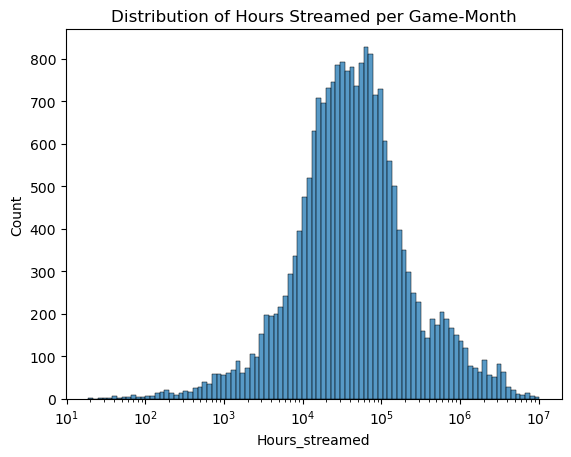

In [18]:
sb.histplot(game['Hours_streamed'], log_scale=True)
plt.title('Distribution of Hours Streamed per Game-Month')
plt.show()

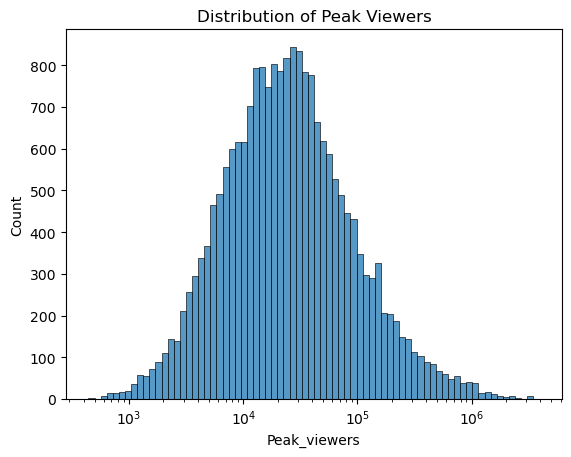

In [19]:
sb.histplot(game['Peak_viewers'], log_scale=True)
plt.title('Distribution of Peak Viewers')
plt.show()

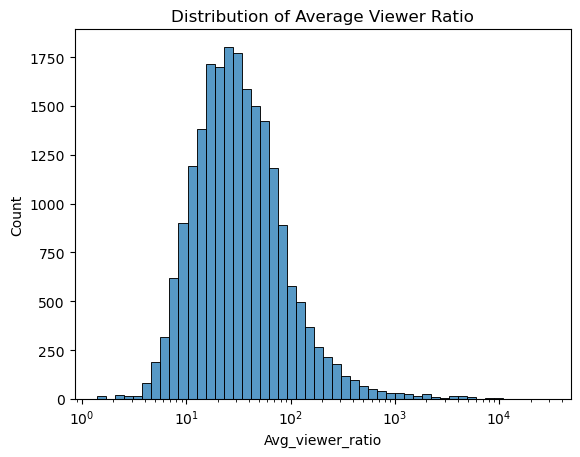

In [20]:
sb.histplot(game['Avg_viewer_ratio'], bins=50,log_scale=True)
plt.title('Distribution of Average Viewer Ratio')
plt.show()

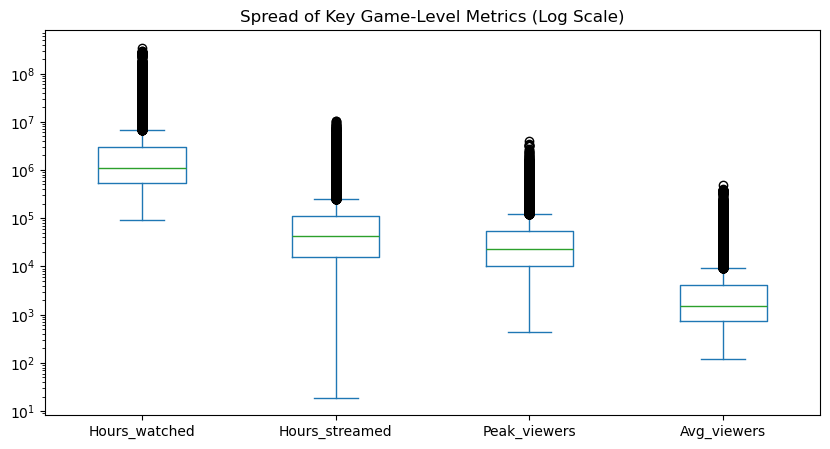

In [21]:
metrics = ['Hours_watched', 'Hours_streamed', 'Peak_viewers', 'Avg_viewers']
game[metrics].apply(lambda x: x).plot(kind='box', logy=True, figsize=(10,5))
plt.title('Spread of Key Game-Level Metrics (Log Scale)')
plt.show()

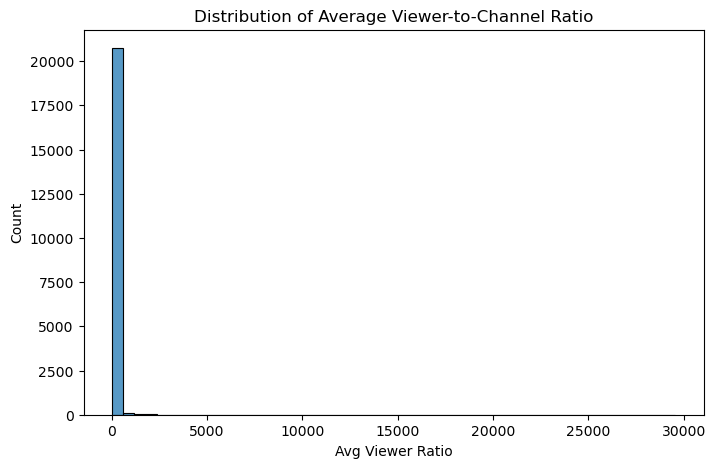

In [22]:
plt.figure(figsize=(8,5))
sb.histplot(game['Avg_viewer_ratio'], bins=50)
plt.title('Distribution of Average Viewer-to-Channel Ratio')
plt.xlabel('Avg Viewer Ratio')
plt.ylabel('Count')
plt.show()

## Platform-Level Time Series Trends

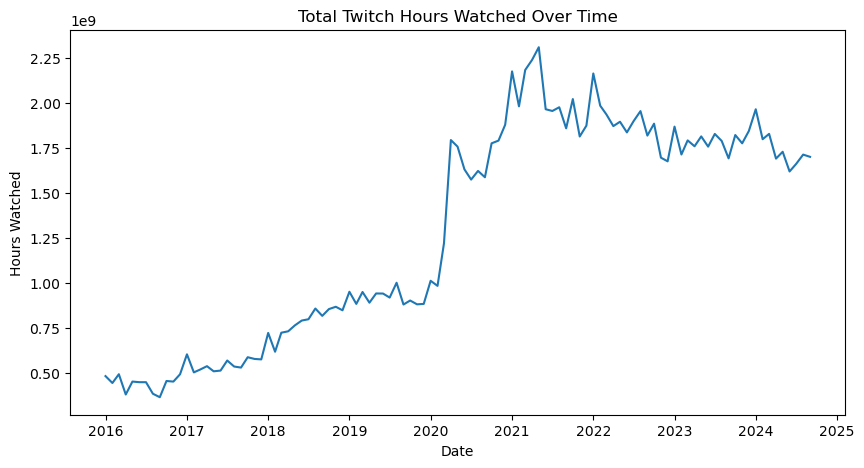

In [24]:
plt.figure(figsize=(10,5))
sb.lineplot(data=platform, x='date', y='Hours_watched')
plt.title('Total Twitch Hours Watched Over Time')
plt.xlabel('Date')
plt.ylabel('Hours Watched')
plt.show()

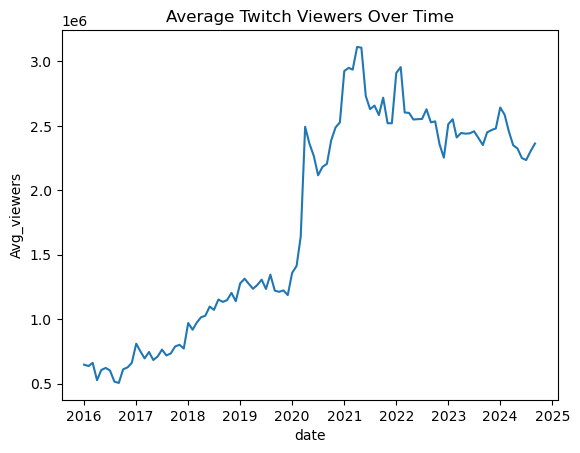

In [25]:
sb.lineplot(data=platform, x='date', y='Avg_viewers')
plt.title('Average Twitch Viewers Over Time')
plt.show()

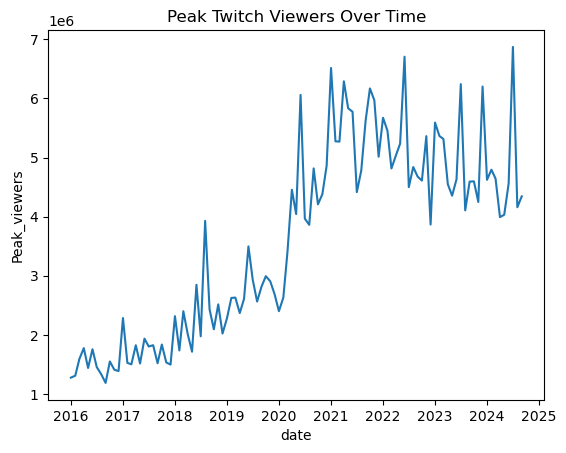

In [26]:
sb.lineplot(data=platform, x='date', y='Peak_viewers')
plt.title('Peak Twitch Viewers Over Time')
plt.show()

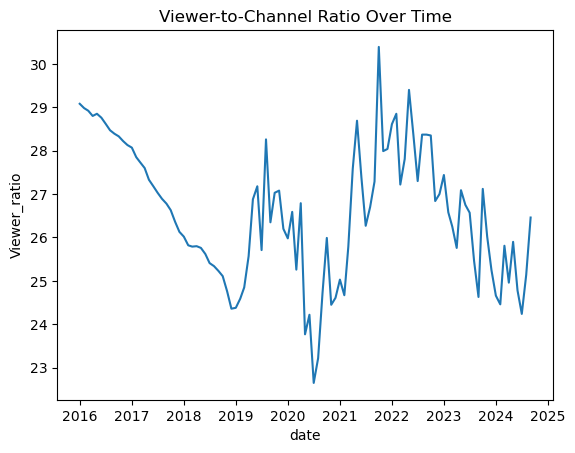

In [27]:
sb.lineplot(data=platform, x='date', y='Viewer_ratio')
plt.title('Viewer-to-Channel Ratio Over Time')
plt.show()

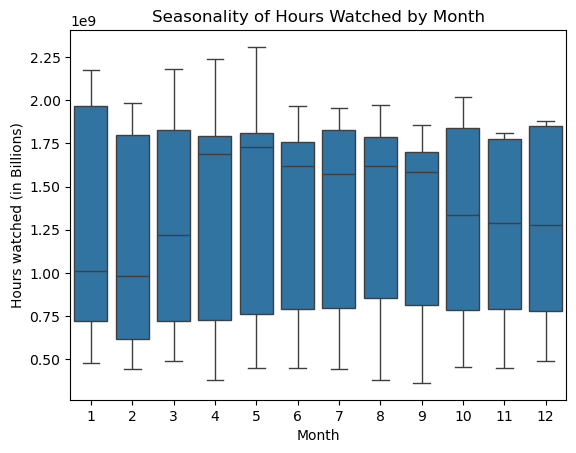

In [28]:
sb.boxplot(data=platform, x='Month', y='Hours_watched')
plt.title('Seasonality of Hours Watched by Month')
plt.ylabel('Hours watched (in Billions)')
plt.show()

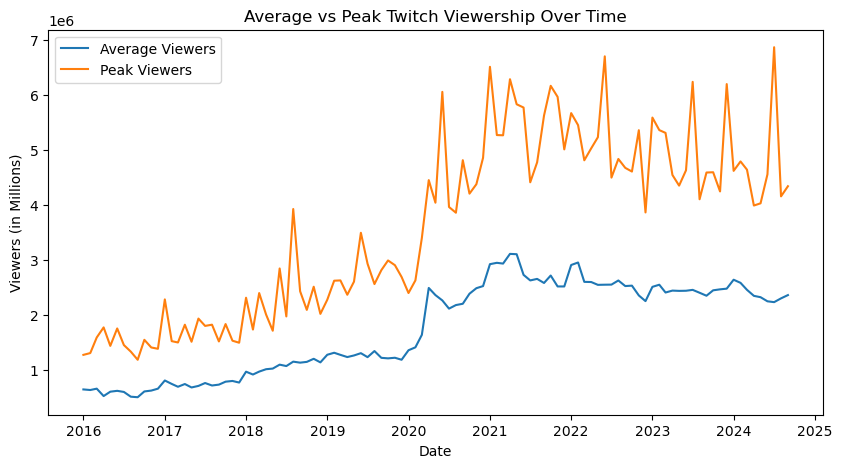

In [29]:
plt.figure(figsize=(10,5))
sb.lineplot(data=platform, x='date', y='Avg_viewers', label='Average Viewers')
sb.lineplot(data=platform, x='date', y='Peak_viewers', label='Peak Viewers')
plt.title('Average vs Peak Twitch Viewership Over Time')
plt.xlabel('Date')
plt.ylabel('Viewers (in Millions)')
plt.legend()
plt.show()

## Game-Level Trends

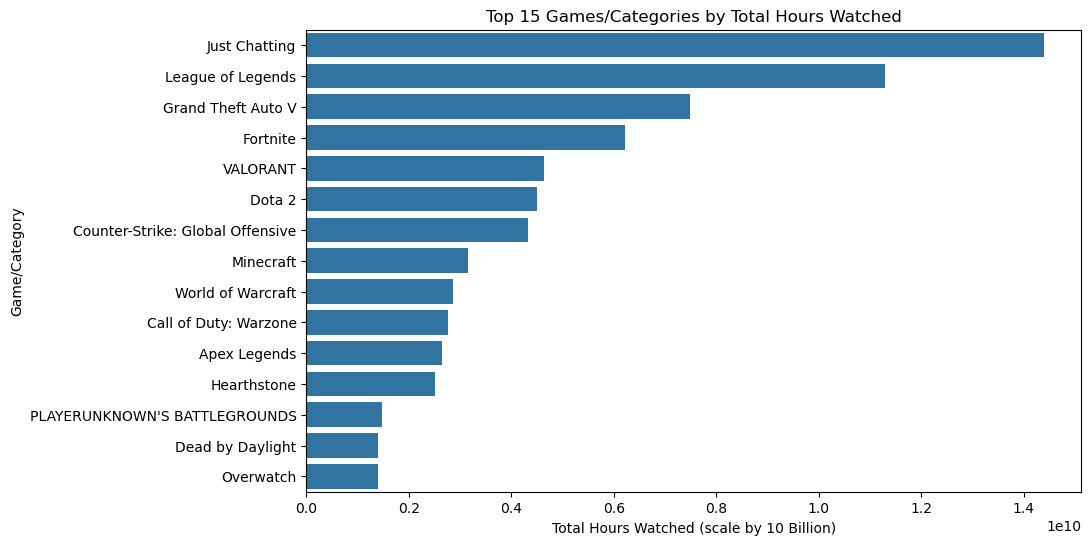

In [31]:
top_games = (
    game.groupby('Game')['Hours_watched']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(10,6))
sb.barplot(data=top_games, x='Hours_watched', y='Game')
plt.title('Top 15 Games/Categories by Total Hours Watched')
plt.xlabel('Total Hours Watched (scale by 10 Billion)')
plt.ylabel('Game/Category')
plt.show()

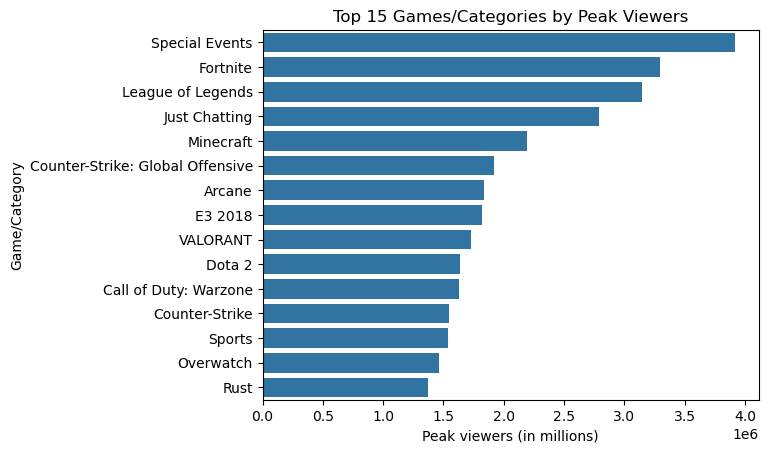

In [32]:
top_peak = (
    game.groupby('Game')['Peak_viewers']
    .max()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

sb.barplot(data=top_peak, x='Peak_viewers', y='Game')
plt.title('Top 15 Games/Categories by Peak Viewers')
plt.xlabel('Peak viewers (in millions)')
plt.ylabel('Game/Category')
plt.show()

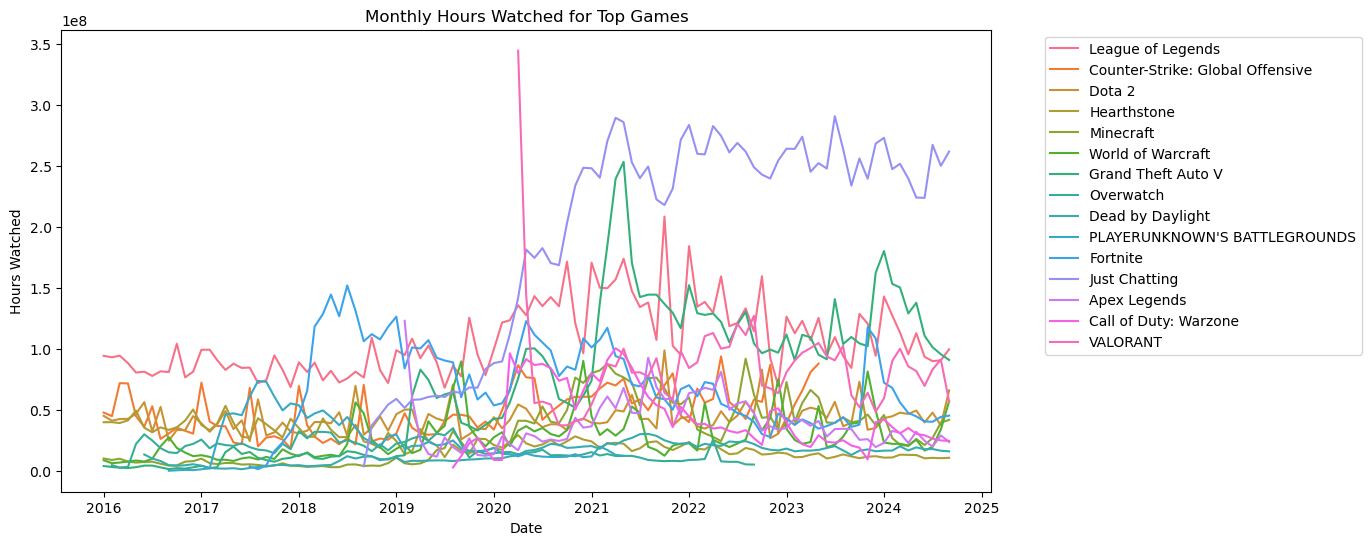

In [33]:
top_game_names = top_games['Game'].tolist()
filtered = game[game['Game'].isin(top_game_names)]

plt.figure(figsize=(12,6))
sb.lineplot(data=filtered, x='date', y='Hours_watched', hue='Game')
plt.title('Monthly Hours Watched for Top Games')
plt.xlabel('Date')
plt.ylabel('Hours Watched')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

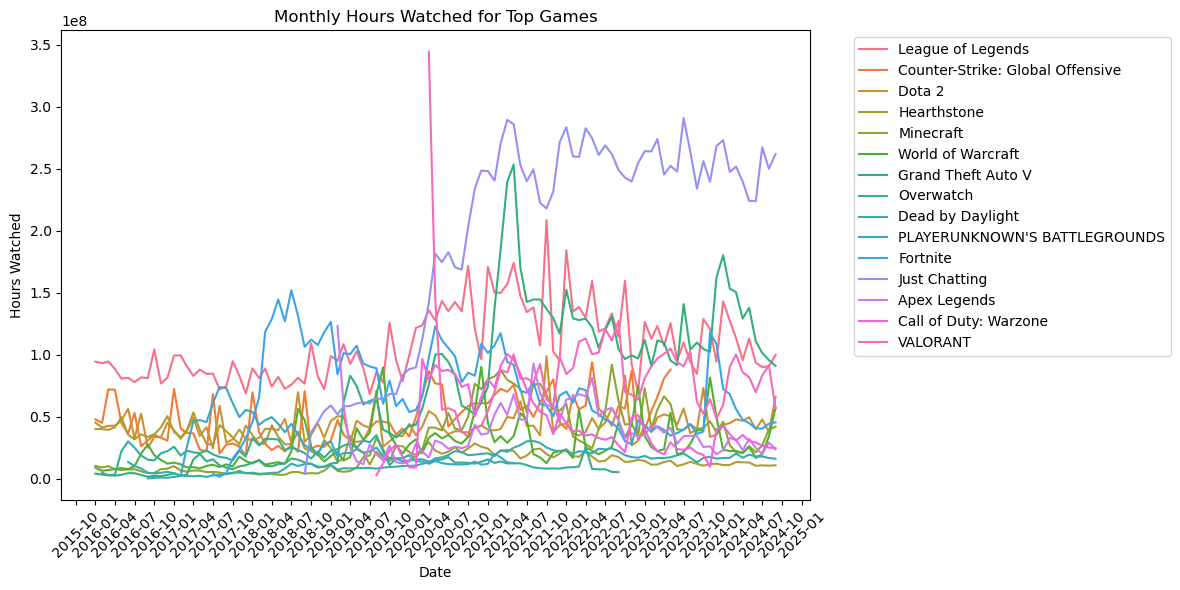

In [34]:
top_game_names = top_games['Game'].tolist()
filtered = game[game['Game'].isin(top_game_names)]

plt.figure(figsize=(12,6))
sb.lineplot(data=filtered, x='date', y='Hours_watched', hue='Game')
plt.title('Monthly Hours Watched for Top Games')
plt.xlabel('Date')
plt.ylabel('Hours Watched')

# Format x-axis to show Year-Month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # show every 3 months
plt.xticks(rotation=45)  # rotate labels for readability

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

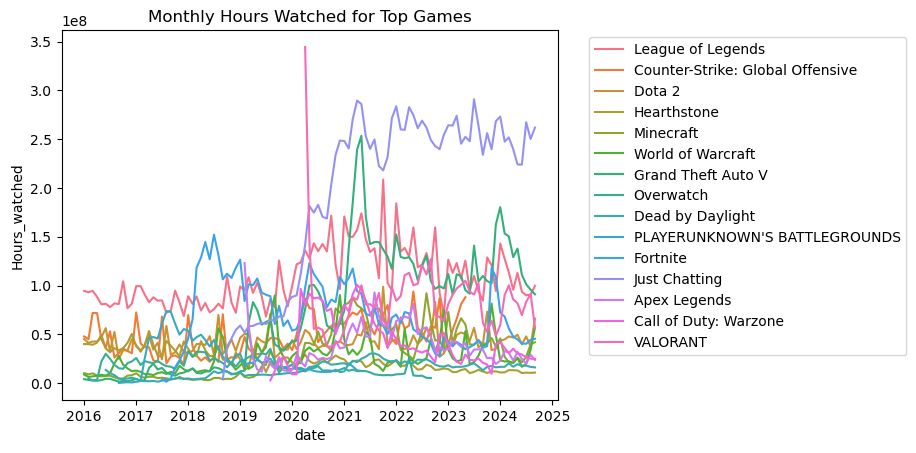

In [35]:
top15 = (
    game.groupby('Game')['Hours_watched']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

top_games = top15['Game'].tolist()
filtered = game[game['Game'].isin(top_games)]

sb.lineplot(data=filtered, x='date', y='Hours_watched', hue='Game')
plt.title('Monthly Hours Watched for Top Games')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

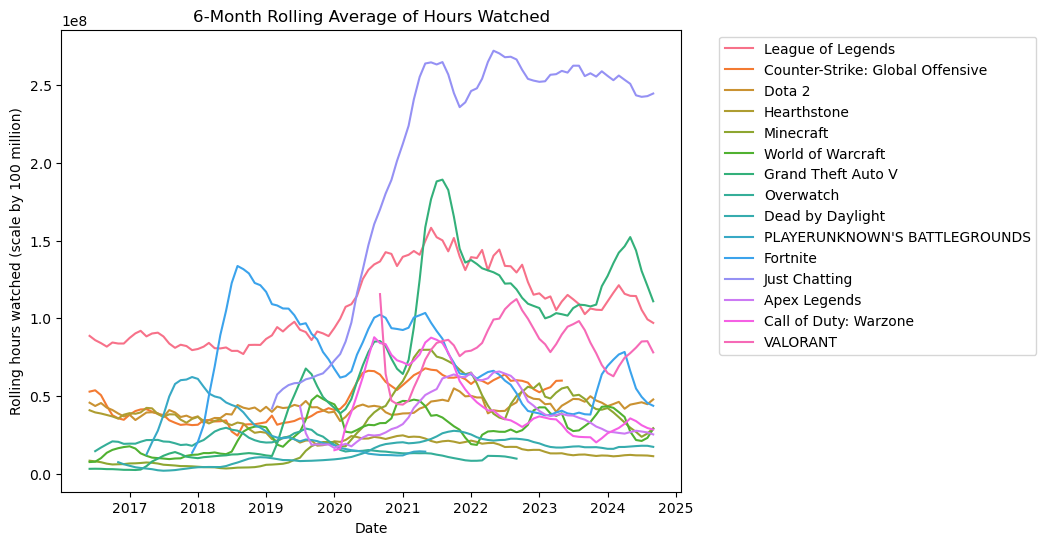

In [36]:
rolling = (
    filtered.sort_values('date')
    .assign(rolling_hours=lambda x: x.groupby('Game')['Hours_watched'].transform(lambda s: s.rolling(6).mean()))
)
plt.figure(figsize=(8,6))
sb.lineplot(data=rolling, x='date', y='rolling_hours', hue='Game')
plt.title('6-Month Rolling Average of Hours Watched')
plt.xlabel('Date')
plt.ylabel('Rolling hours watched (scale by 100 million)')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

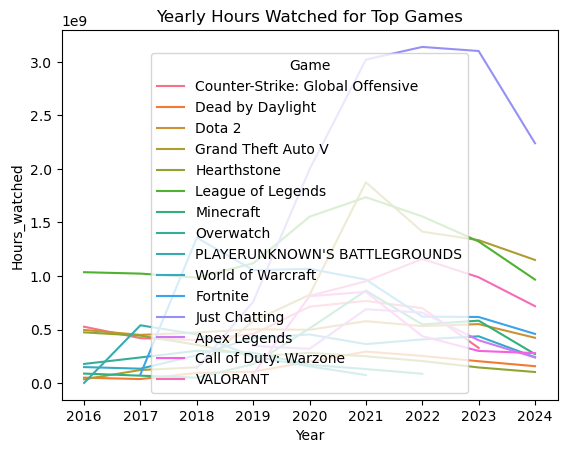

In [37]:
yearly = game.groupby(['Year','Game'])['Hours_watched'].sum().reset_index()

sb.lineplot(
    data=yearly[yearly['Game'].isin(top_games)],
    x='Year', y='Hours_watched', hue='Game'
)
plt.title('Yearly Hours Watched for Top Games')
plt.show()

## Relationship Analysis

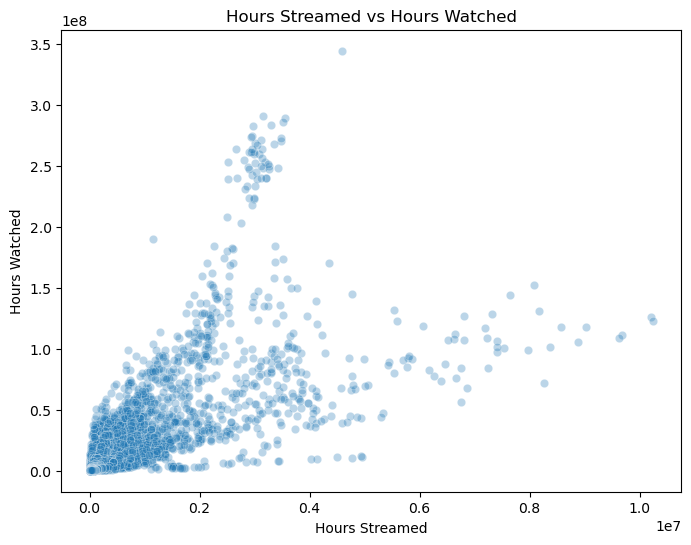

In [39]:
plt.figure(figsize=(8,6))
sb.scatterplot(
    data=game,
    x='Hours_streamed',
    y='Hours_watched',
    alpha=0.3
)
plt.title('Hours Streamed vs Hours Watched')
plt.xlabel('Hours Streamed')
plt.ylabel('Hours Watched')
plt.show()

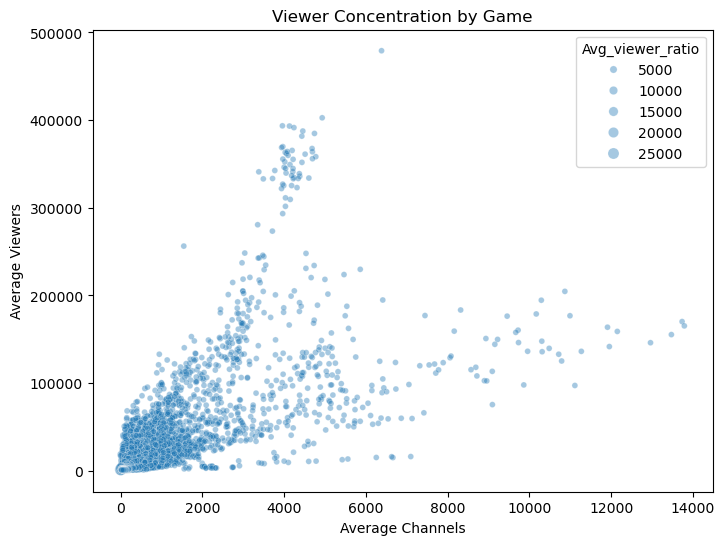

In [40]:
plt.figure(figsize=(8,6))
sb.scatterplot(
    data=game,
    x='Avg_channels',
    y='Avg_viewers',
    size='Avg_viewer_ratio',
    alpha=0.4
)
plt.title('Viewer Concentration by Game')
plt.xlabel('Average Channels')
plt.ylabel('Average Viewers')
plt.show()

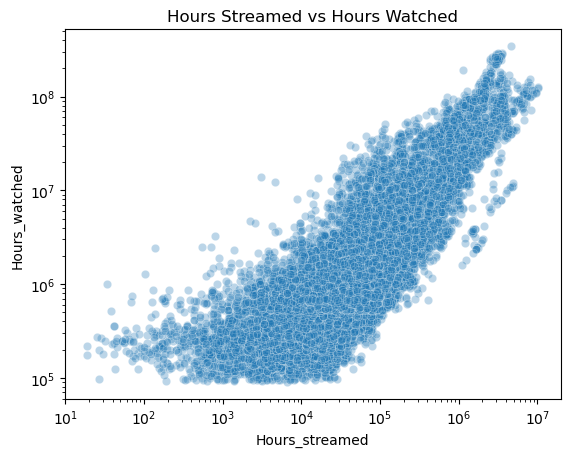

In [41]:
sb.scatterplot(data=game, x='Hours_streamed', y='Hours_watched', alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.title('Hours Streamed vs Hours Watched')
plt.show()

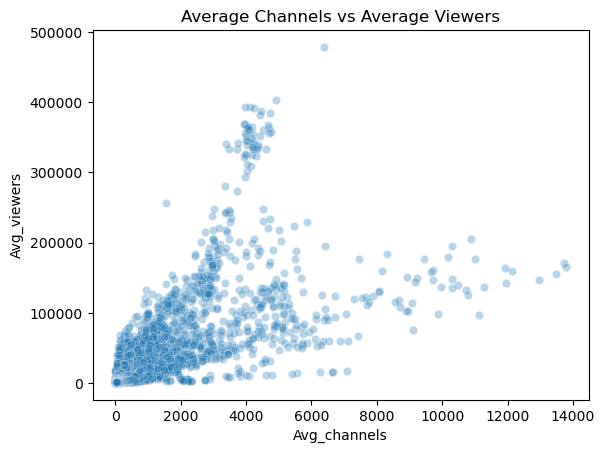

In [42]:
sb.scatterplot(data=game, x='Avg_channels', y='Avg_viewers', alpha=0.3)
plt.title('Average Channels vs Average Viewers')
plt.show()

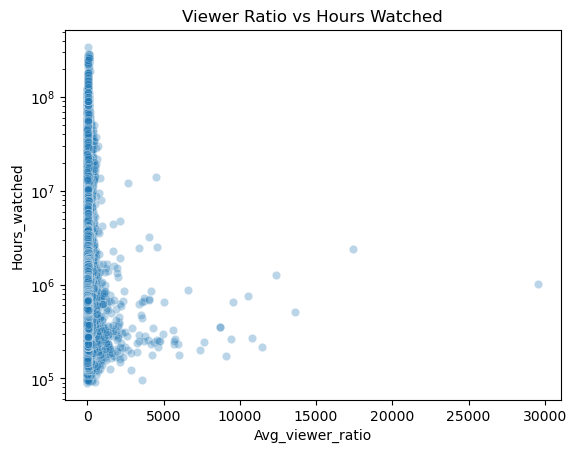

In [43]:
sb.scatterplot(data=game, x='Avg_viewer_ratio', y='Hours_watched', alpha=0.3)
plt.yscale('log')
plt.title('Viewer Ratio vs Hours Watched')
plt.show()

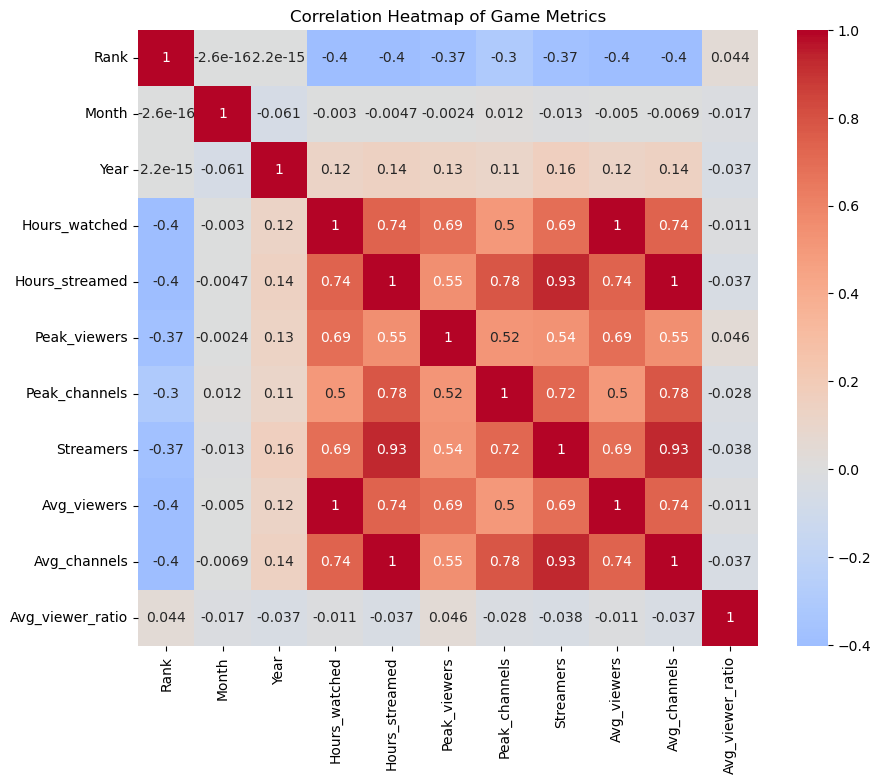

In [44]:
corr = game.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sb.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Game Metrics')
plt.show()

In [45]:
corr

,Rank,Month,Year,Hours_watched,Hours_streamed,Peak_viewers,Peak_channels,Streamers,Avg_viewers,Avg_channels,Avg_viewer_ratio
Rank,1.000000e+00,-2.639090e-16,2.189493e-15,-0.402867,-0.399622,-0.371577,-0.302693,-0.374219,-0.402842,-0.399713,0.044131
Month,-2.639090e-16,1.000000e+00,-6.134232e-02,-0.003032,-0.004666,-0.002449,0.011848,-0.012618,-0.005014,-0.006902,-0.016911
Year,2.189493e-15,-6.134232e-02,1.000000e+00,0.121111,0.141915,0.129644,0.109067,0.157806,0.121227,0.142083,-0.037160
Hours_watched,-4.028674e-01,-3.031743e-03,1.211115e-01,1.000000,0.735885,0.689176,0.501478,0.691853,0.999583,0.735737,-0.010573
Hours_streamed,-3.996215e-01,-4.665564e-03,1.419154e-01,0.735885,1.000000,0.550507,0.782647,0.932295,0.735529,0.999572,-0.037283
Peak_viewers,-3.715774e-01,-2.448519e-03,1.296436e-01,0.689176,0.550507,1.000000,0.521680,0.536368,0.688892,0.550542,0.046198
Peak_channels,-3.026925e-01,1.184789e-02,1.090668e-01,0.501478,0.782647,0.521680,1.000000,0.724084,0.501910,0.783137,-0.027692
Streamers,-3.742191e-01,-1.261757e-02,1.578062e-01,0.691853,0.932295,0.536368,0.724084,1.000000,0.691818,0.932178,-0.038304
Avg_viewers,-4.028419e-01,-5.013994e-03,1.212268e-01,0.999583,0.735529,0.688892,0.501910,0.691818,1.000000,0.736028,-0.010599
Avg_channels,-3.997135e-01,-6.902159e-03,1.420833e-01,0.735737,0.999572,0.550542,0.783137,0.932178,0.736028,1.000000,-0.037266


## Comparing Game to Platform Trends

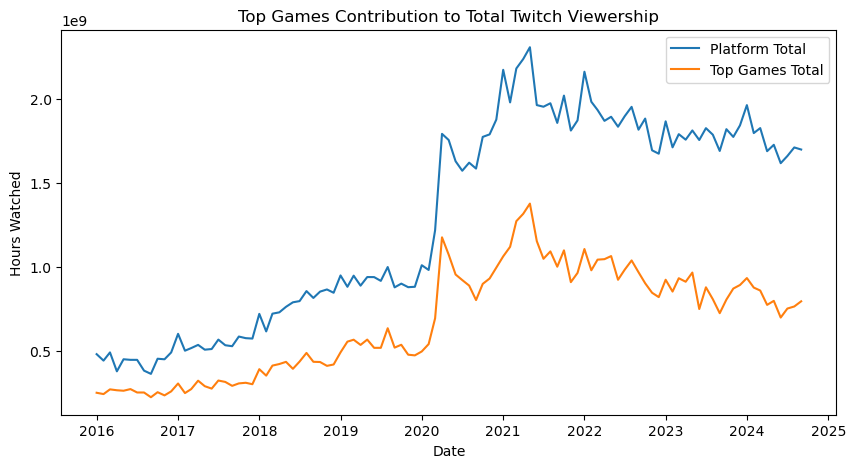

In [47]:
monthly_top_games = (
    filtered.groupby('date')['Hours_watched']
    .sum()
    .reset_index()
)

merged = platform.merge(monthly_top_games, on='date', how='left', suffixes=('_platform', '_top_games'))

plt.figure(figsize=(10,5))
sb.lineplot(data=merged, x='date', y='Hours_watched_platform', label='Platform Total')
sb.lineplot(data=merged, x='date', y='Hours_watched_top_games', label='Top Games Total')
plt.title('Top Games Contribution to Total Twitch Viewership')
plt.xlabel('Date')
plt.ylabel('Hours Watched')
plt.legend()
plt.show()

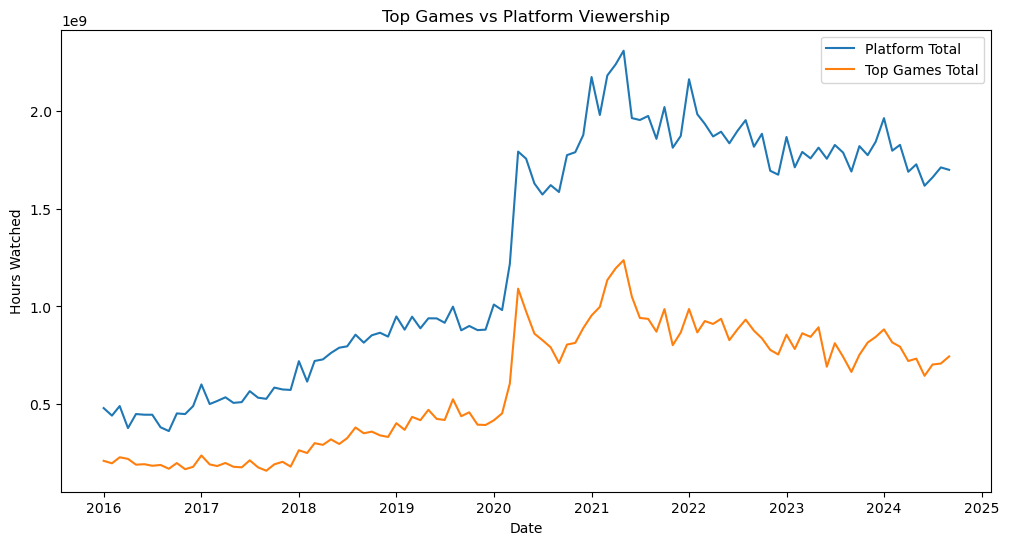

In [48]:
top_games = game.groupby('Game')['Hours_watched'].sum().sort_values(ascending=False).head(10).index.tolist()
filtered = game[game['Game'].isin(top_games)]

top_monthly = (
    filtered.groupby('date')['Hours_watched']
    .sum()
    .reset_index()
)

merged = platform.merge(top_monthly, on='date', how='left', suffixes=('_platform','_topgames'))

plt.figure(figsize=(12,6))
sb.lineplot(data=merged, x='date', y='Hours_watched_platform', label='Platform Total')
sb.lineplot(data=merged, x='date', y='Hours_watched_topgames', label='Top Games Total')
plt.title('Top Games vs Platform Viewership')
plt.ylabel('Hours Watched')
plt.xlabel('Date')
plt.legend()
plt.show()

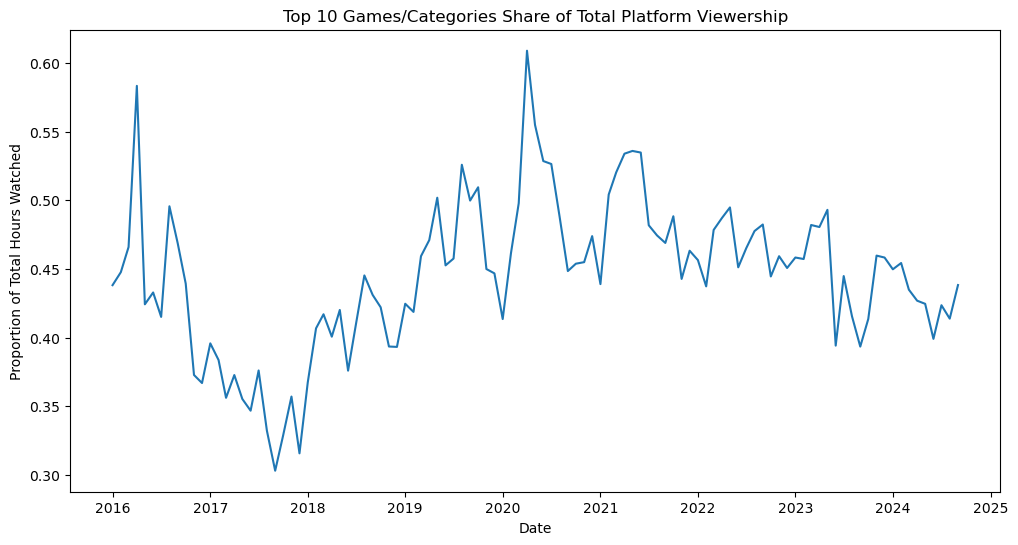

In [49]:
merged['top_game_share'] = merged['Hours_watched_topgames'] / merged['Hours_watched_platform']

plt.figure(figsize=(12,6))
sb.lineplot(data=merged, x='date', y='top_game_share')
plt.title('Top 10 Games/Categories Share of Total Platform Viewership')
plt.ylabel('Proportion of Total Hours Watched')
plt.xlabel('Date')
plt.show()